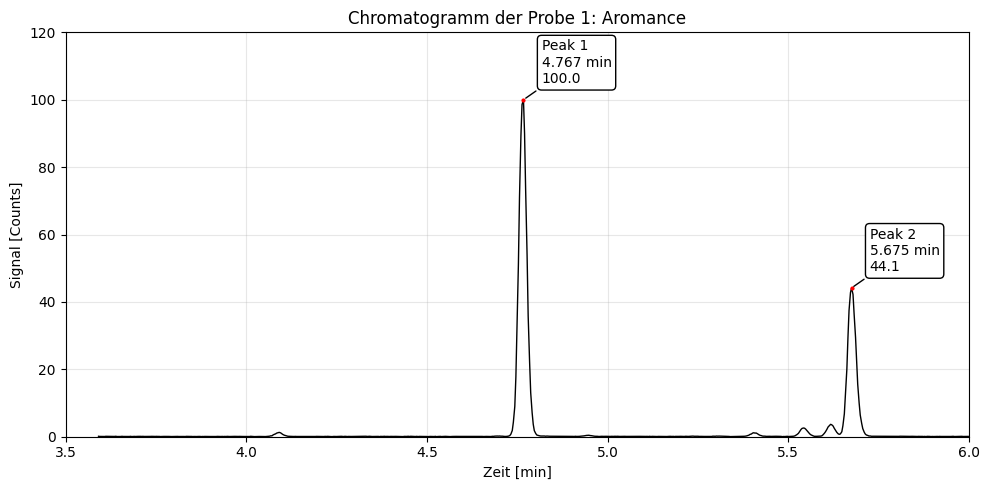

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# =========================
# 1) CSV-Datei einlesen
# =========================
df = pd.read_csv(
    "Aro_1.csv",
    comment="#",
    sep=",",
    header=None,
    names=["Point", "X", "Y"]
)

# =========================
# 2) Störzeichen entfernen & in Zahlen umwandeln
# =========================
df["X"] = df["X"].astype(str).str.replace(";", "", regex=False)
df["Y"] = df["Y"].astype(str).str.replace(";", "", regex=False)

df["X"] = pd.to_numeric(df["X"], errors="coerce")
df["Y"] = pd.to_numeric(df["Y"], errors="coerce")

df = df.dropna(subset=["X", "Y"])

# =========================
# 3) Peaks finden (nur im Bereich 3.5–6 min)
# =========================
df_plot = df[(df["X"] >= 3.5) & (df["X"] <= 6)]

peaks, _ = find_peaks(df_plot["Y"], prominence=5)

# 4 größte Peaks auswählen
peak_values = df_plot["Y"].iloc[peaks]
top4 = peak_values.nlargest(4).index

# Nach Zeit sortieren
top4_sorted = top4.sort_values(key=lambda x: df_plot["X"].loc[x])

# =========================
# 4) Plot
# =========================
plt.figure(figsize=(10, 5))
plt.plot(df_plot["X"], df_plot["Y"], linewidth=1, color="black")

plt.xlabel("Zeit [min]")
plt.ylabel("Signal [Counts]")
plt.title("Chromatogramm der Probe 1: Aromance")
plt.grid(True, alpha=0.3)

# =========================
# 5) Peaks markieren + beschriften
# =========================
for i, p in enumerate(top4_sorted, start=1):
    x = df_plot["X"].loc[p]
    y = df_plot["Y"].loc[p]

    # Punkt markieren
    plt.plot(x, y, "ro", markersize=2)

    # Textposition
    text_x = x + 0.05
    text_y = y + df_plot["Y"].max() * 0.05

    # Linie + Text
    plt.annotate(
        f"Peak {i}\n{x:.3f} min\n{y:.1f}",
        xy=(x, y),
        xytext=(text_x, text_y),
        arrowprops=dict(arrowstyle="-", color="black"),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"),
        fontsize=10
    )

# Achsenbegrenzung
plt.xlim(3.5, 6)
plt.ylim(0, df_plot["Y"].max() * 1.2)

plt.tight_layout()
plt.show()

=== KALIBRIERUNG ===
Steigung b              = 1.437679
Ordinatenabschnitt a    = -0.014023
Reststandardabw. sy     = 0.005494
Qxx                     = 0.651854
n (Kalibriermessungen)  = 10
ȳ (Mittelwert Kalibers) = 0.764629

=== PROBE 1 aromance – Einzelergebnisse ===
Datei: Aro_1.csv
  A_pinen     = 100.000
  A_cineol    = 44.147
  A_cin/A_pin = 0.441472
  c_cineol    = 0.316826 mg/mL

=== PROBE 1 aromance – Statistik ===
Anzahl Probenmessungen m   = 1
Mittelwert Probensignal ŷ_m= 0.441472
Mittelwert Kalibriersignal ȳ = 0.764629
s_x (Messlösung)           = 4.146960e-03 mg/mL
s_x (auf Öl bezogen)       = 4.146960e-03 mg/mL (mit D = 1.0)



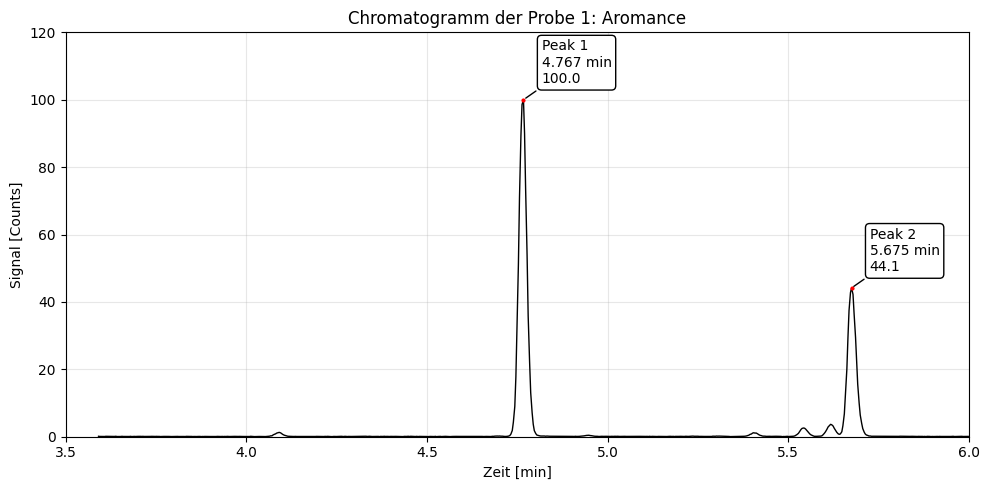

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

# ============================================================
# HILFSFUNKTION: CSV-Chromatogramm einlesen und säubern
# ============================================================
def lese_chromatogramm(csv_datei):
    df = pd.read_csv(
        csv_datei,
        comment="#",
        sep=",",
        header=None,
        names=["Point", "X", "Y"]
    )

    df["X"] = df["X"].astype(str).str.replace(";", "", regex=False)
    df["Y"] = df["Y"].astype(str).str.replace(";", "", regex=False)

    df["X"] = pd.to_numeric(df["X"], errors="coerce")
    df["Y"] = pd.to_numeric(df["Y"], errors="coerce")

    df = df.dropna(subset=["X", "Y"])
    return df


# ============================================================
# 1) KALIBRIERUNG AUS EXCEL EINLESEN
#    (Template_GC.xlsx – Spalten B = c, F = A_Cin/A_Pin)
# ============================================================
cal = pd.read_excel(
    "Template_GC.xlsx",
    engine="openpyxl",
    usecols="B,F",
    skiprows=3,        # ggf. anpassen, falls andere Zeile
    nrows=12           # Anzahl Kalibrierpunkte (hier 10 Messungen)
)

cal.columns = ["c", "A_ratio"]  # c(Cineol), A(Cin)/A(Pin)

x_cal = cal["c"].to_numpy()
y_cal = cal["A_ratio"].to_numpy()
n = len(x_cal)                   # Anzahl Kalibriermessungen


# -------- lineare Regression y = b*x + a --------
b, a = np.polyfit(x_cal, y_cal, 1)
y_fit = b * x_cal + a

# Reststandardabweichung sy
resid = y_cal - y_fit
f = n - 2
sy = np.sqrt(np.sum(resid**2) / f)

# Quadratsumme Qxx und Mittelwert Kalibriersignal
x_mean = np.mean(x_cal)
Qxx = np.sum((x_cal - x_mean)**2)
y_mean = np.mean(y_cal)

print("=== KALIBRIERUNG ===")
print(f"Steigung b              = {b:.6f}")
print(f"Ordinatenabschnitt a    = {a:.6f}")
print(f"Reststandardabw. sy     = {sy:.6f}")
print(f"Qxx                     = {Qxx:.6f}")
print(f"n (Kalibriermessungen)  = {n}")
print(f"ȳ (Mittelwert Kalibers) = {y_mean:.6f}")
print()


# ============================================================
# 2) PROBE 1: MEHRERE CHROMATOGRAMME AUSWERTEN
# ============================================================

# HIER deine Dateien für Probe 1 eintragen:
probe_dateien = [
    "Aro_1.csv",
    # "Aro_1_2.csv",
    # "Aro_1_3.csv",
]

ergebnisse = []  # Liste für (datei, A_pinen, A_cin, ratio, c_cin)

for csv_datei in probe_dateien:
    df = lese_chromatogramm(csv_datei)

    # Bereich 3,5–6 min (Pinen + Cineol)
    df_plot = df[(df["X"] >= 3.5) & (df["X"] <= 6)].copy()

    # Peaks finden
    peaks, _ = find_peaks(df_plot["Y"], prominence=5)

    peak_values = df_plot["Y"].iloc[peaks]
    # bis zu 4 größte Peaks nehmen
    top = peak_values.nlargest(4).index
    top_sorted = top.sort_values(key=lambda idx: df_plot["X"].loc[idx])

    if len(top_sorted) < 2:
        raise RuntimeError(f"In {csv_datei} wurden im Bereich 3.5–6 min weniger als 2 Peaks gefunden.")

    # Annahme: links Pinen, rechts Cineol
    idx_pinen = top_sorted[0]
    idx_cineol = top_sorted[1]

    A_pinen = df_plot.loc[idx_pinen, "Y"]
    A_cineol = df_plot.loc[idx_cineol, "Y"]
    ratio = A_cineol / A_pinen
    c_cineol = (ratio - a) / b   # aus RGP: x = (y - a)/b

    ergebnisse.append((csv_datei, A_pinen, A_cineol, ratio, c_cineol))

# ============================================================
# 3) PROBENSTATISTIK FÜR PROBE 1
# ============================================================
ratios = np.array([r[3] for r in ergebnisse])
c_values = np.array([r[4] for r in ergebnisse])

m = len(ratios)        # Anzahl Probenmessungen
y_m = ratios.mean()    # Mittelwert Probensignal

# Streuung des Analysenergebnisses s_x (auf Messlösung bezogen)
sx_mess = sy / abs(b) * np.sqrt(
    1/m + 1/n + ((y_m - y_mean)**2) / (b**2 * Qxx)
)

# Falls Verdünnungsfaktor D (z.B. 100) vorliegt:
D = 1.0   # HIER ggf. Verdünnungsfaktor der Messlösung eintragen
sx_oel = sx_mess * D

print("=== PROBE 1 aromance – Einzelergebnisse ===")
for datei, A_pinen, A_cineol, ratio, c_cineol in ergebnisse:
    print(f"Datei: {datei}")
    print(f"  A_pinen     = {A_pinen:.3f}")
    print(f"  A_cineol    = {A_cineol:.3f}")
    print(f"  A_cin/A_pin = {ratio:.6f}")
    print(f"  c_cineol    = {c_cineol:.6f} mg/mL")
    print()

print("=== PROBE 1 aromance – Statistik ===")
print(f"Anzahl Probenmessungen m   = {m}")
print(f"Mittelwert Probensignal ŷ_m= {y_m:.6f}")
print(f"Mittelwert Kalibriersignal ȳ = {y_mean:.6f}")
print(f"s_x (Messlösung)           = {sx_mess:.6e} mg/mL")
print(f"s_x (auf Öl bezogen)       = {sx_oel:.6e} mg/mL (mit D = {D})")
print()


# ============================================================
# 4) Plot für EIN Chromatogramm (z.B. das erste)
# ============================================================
# Nur zur Visualisierung – wie dein ursprünglicher Plot
df = lese_chromatogramm(probe_dateien[0])
df_plot = df[(df["X"] >= 3.5) & (df["X"] <= 6)].copy()

peaks, _ = find_peaks(df_plot["Y"], prominence=5)
peak_values = df_plot["Y"].iloc[peaks]
top = peak_values.nlargest(4).index
top_sorted = top.sort_values(key=lambda idx: df_plot["X"].loc[idx])

plt.figure(figsize=(10, 5))
plt.plot(df_plot["X"], df_plot["Y"], linewidth=1, color="black")
plt.xlabel("Zeit [min]")
plt.ylabel("Signal [Counts]")
plt.title("Chromatogramm der Probe 1: Aromance")
plt.grid(True, alpha=0.3)

for i, p in enumerate(top_sorted, start=1):
    x = df_plot["X"].loc[p]
    y = df_plot["Y"].loc[p]
    plt.plot(x, y, "ro", markersize=2)
    text_x = x + 0.05
    text_y = y + df_plot["Y"].max() * 0.05
    plt.annotate(
        f"Peak {i}\n{x:.3f} min\n{y:.1f}",
        xy=(x, y),
        xytext=(text_x, text_y),
        arrowprops=dict(arrowstyle="-", color="black"),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"),
        fontsize=10
    )

plt.xlim(3.5, 6)
plt.ylim(0, df_plot["Y"].max() * 1.2)
plt.tight_layout()
plt.show()

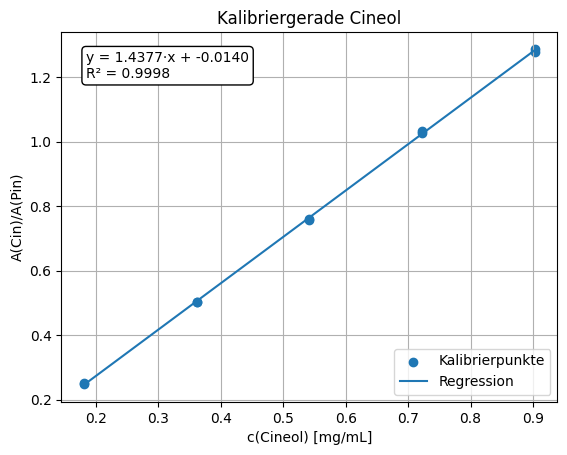

=== Darstellung der Kalibriergerade ===
Steigung b               = 1.437679
Ordinatenabschnitt a     = -0.014023
Bestimmtheitsmaß R²      = 0.9998
Korrelationskoeffizient R= 0.9999
Reststandardabweichung sy= 0.005494
Quadratsumme Qxx         = 0.651854
Anzahl Kalibriermessung n= 10
Freiheitsgrade f         = 8
Mittelwert Kalibriersignal ȳ = 0.764629
t-Wert (einseitig, 95 %) = 1.8595
t-Wert (zweiseitig, 95 %)= 2.3060

=== Nachweis- / Bestimmungsgrenze ===
LOD Messlösung [mg/mL]   = 1.146487e-02
LOQ Messlösung [mg/mL]   = 3.821622e-02
LOD Öl [mg/mL]           = 1.146487e-02  (mit Verdünnungsfaktor = 1.0)
LOQ Öl [mg/mL]           = 3.821622e-02  (mit Verdünnungsfaktor = 1.0)

=== Probe 1 aromance ===
Anzahl Probenmessungen m      = 3
Mittelwert Probensignal ŷ_m   = 0.472597
Mittelwert Kalibriersignal ȳ  = 0.764629
s_x (Messlösung) [mg/mL]      = 2.693174e-03
s_x (Öl) [mg/mL]              = 4.488624e-02  (mit V_ges/V_Probe = 16.666666666666668)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t

# ===============================
# 1) Kalibrierung laden
# ===============================
df = pd.read_excel(
    "Template_GC.xlsx",
    engine="openpyxl",
    usecols="B,F",    # B = c(Cineol), F = A(Cin)/A(Pin)
    skiprows=3,       # ggf. anpassen, falls andere Startzeile
    nrows=12          # Anzahl Kalibrierpunkte (bei dir 10 Messungen)
)

df.columns = ["c", "A_ratio"]   # x und y

x = df["c"].to_numpy()
y = df["A_ratio"].to_numpy()

# ===============================
# 2) Lineare Regression
# ===============================
# y = b * x + a
b, a = np.polyfit(x, y, 1)      # b = Steigung, a = Achsenabschnitt
y_fit = b * x + a

# Korrelationskoeffizient R und R^2
R = np.corrcoef(x, y)[0, 1]
R2 = R**2

# ===============================
# 3) Statistik: sy, Qxx, n, f, t-Werte
# ===============================
n = len(x)               # Anzahl Kalibriermessungen
f = n - 2                # Freiheitsgrade bei einfacher Regression

residuals = y - y_fit
sy = np.sqrt(np.sum(residuals**2) / f)   # Reststandardabweichung

x_mean = np.mean(x)
Qxx = np.sum((x - x_mean)**2)           # Quadratsumme Qxx

y_mean = np.mean(y)                     # Mittelwert Kalibriersignal ȳ

# t-Werte für 95 % (alpha = 0.05)
alpha = 0.05
t_einseitig = t.ppf(1 - alpha, df=f)
t_zweiseitig = t.ppf(1 - alpha/2, df=f)

# ===============================
# 4) LOD / LOQ (auf Messlösung bezogen)
# ===============================
LOD_mess = 3 * sy / abs(b)    # mg/mL
LOQ_mess = 10 * sy / abs(b)   # mg/mL

# Verdünnungsfaktor (falls du auf das Öl umrechnen willst)
D_verduennung = 1.0           # bei dir aktuell 1
LOD_oel = LOD_mess * D_verduennung
LOQ_oel = LOQ_mess * D_verduennung

# ===============================
# 5) Probe 1 aromance: s_x nach deiner Formel
# ===============================
# A(Cin)/A(Pin)-Werte aus deiner Tabelle "Bestimmung der Probe" (Probe 1)
y_probe = np.array([
    0.4741035,
    0.4700185,
    0.4736701,
])

m = len(y_probe)              # Anzahl Probenmessungen
y_m = y_probe.mean()          # Mittelwert Probensignal ŷ_m

# Formel:
# s_x = (s_y / |b|) * sqrt( 1/n + 1/m + ((y_m - y_mean)^2 / (b^2 * Qxx)) )
sx_mess = (sy / abs(b)) * np.sqrt(
    1/n + 1/m + ((y_m - y_mean)**2) / (b**2 * Qxx)
)

# Falls zusätzlich s_x aufs Öl umgerechnet werden soll:
# s_x(Öl) = s_x * V_ges / V_Probe  -> hier nur Platzhalter
V_ges = 1.0      # z.B. 1.0 mL
V_probe = 0.060    # z.B. 0.01 mL = 10 µL, dann hier 0.01 eintragen
f_vol = V_ges / V_probe
sx_oel = sx_mess * f_vol

# ===============================
# 6) Plot der Kalibriergeraden
# ===============================
plt.figure()
plt.scatter(x, y, label="Kalibrierpunkte")
plt.plot(x, y_fit, label="Regression")

plt.xlabel("c(Cineol) [mg/mL]")
plt.ylabel("A(Cin)/A(Pin)")
plt.title("Kalibriergerade Cineol")
plt.grid(True)

plt.text(
    0.05, 0.95,
    f"y = {b:.4f}·x + {a:.4f}\nR² = {R2:.4f}",
    transform=plt.gca().transAxes,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white")
)

plt.legend()
plt.show()

# ===============================
# 7) Ergebnisse ausgeben (für deine Tabelle)
# ===============================
print("=== Darstellung der Kalibriergerade ===")
print(f"Steigung b               = {b:.6f}")
print(f"Ordinatenabschnitt a     = {a:.6f}")
print(f"Bestimmtheitsmaß R²      = {R2:.4f}")
print(f"Korrelationskoeffizient R= {R:.4f}")
print(f"Reststandardabweichung sy= {sy:.6f}")
print(f"Quadratsumme Qxx         = {Qxx:.6f}")
print(f"Anzahl Kalibriermessung n= {n}")
print(f"Freiheitsgrade f         = {f}")
print(f"Mittelwert Kalibriersignal ȳ = {y_mean:.6f}")
print(f"t-Wert (einseitig, 95 %) = {t_einseitig:.4f}")
print(f"t-Wert (zweiseitig, 95 %)= {t_zweiseitig:.4f}")
print()
print("=== Nachweis- / Bestimmungsgrenze ===")
print(f"LOD Messlösung [mg/mL]   = {LOD_mess:.6e}")
print(f"LOQ Messlösung [mg/mL]   = {LOQ_mess:.6e}")
print(f"LOD Öl [mg/mL]           = {LOD_oel:.6e}  (mit Verdünnungsfaktor = {D_verduennung})")
print(f"LOQ Öl [mg/mL]           = {LOQ_oel:.6e}  (mit Verdünnungsfaktor = {D_verduennung})")
print()
print("=== Probe 1 aromance ===")
print(f"Anzahl Probenmessungen m      = {m}")
print(f"Mittelwert Probensignal ŷ_m   = {y_m:.6f}")
print(f"Mittelwert Kalibriersignal ȳ  = {y_mean:.6f}")
print(f"s_x (Messlösung) [mg/mL]      = {sx_mess:.6e}")
print(f"s_x (Öl) [mg/mL]              = {sx_oel:.6e}  (mit V_ges/V_Probe = {f_vol})")

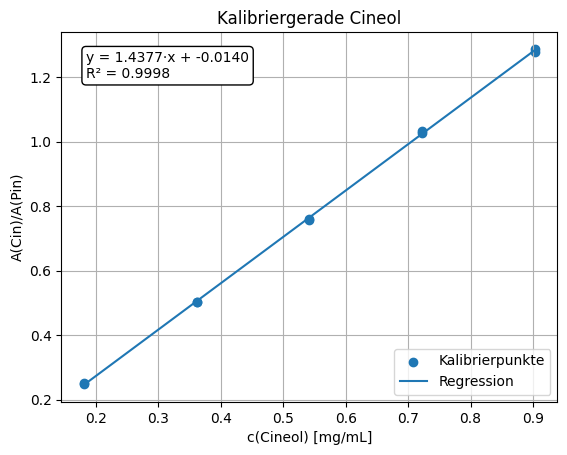

=== Darstellung der Kalibriergerade ===
Steigung b               = 1.437679
Ordinatenabschnitt a     = -0.014023
Bestimmtheitsmaß R²      = 0.9998
Korrelationskoeffizient R= 0.9999
Reststandardabweichung sy= 0.005494
Quadratsumme Qxx         = 0.651854
Anzahl Kalibriermessung n= 10
Freiheitsgrade f         = 8
Mittelwert Kalibriersignal ȳ = 0.764629
t-Wert (einseitig, 95 %) = 1.8595
t-Wert (zweiseitig, 95 %)= 2.3060

=== Nachweis- / Bestimmungsgrenze ===
LOD Messlösung [mg/mL]   = 1.146487e-02
LOQ Messlösung [mg/mL]   = 3.821622e-02
LOD Öl [mg/mL]           = 1.146487e-02  (mit Verdünnungsfaktor = 1.0)
LOQ Öl [mg/mL]           = 3.821622e-02  (mit Verdünnungsfaktor = 1.0)

=== Probe 1 aromance – Messlösung ===
Anzahl Probenmessungen m          = 3
Einzelwerte c (Messlösung) [mg/mL]= [0.33952393 0.33668255 0.33922247]
Mittelwert c (Messlösung) [mg/mL] = 0.338476
Mittelwert Probensignal ŷ_m       = 0.472597
s_x (Messlösung) [mg/mL]          = 2.693174e-03
T_x (Messlösung) [mg/mL]        

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t

# ===============================
# 1) Kalibrierung laden
# ===============================
df = pd.read_excel(
    "Template_GC.xlsx",
    engine="openpyxl",
    usecols="B,F",    # B = c(Cineol), F = A(Cin)/A(Pin)
    skiprows=3,       # ggf. anpassen, falls andere Startzeile
    nrows=12          # Anzahl Kalibrierpunkte (bei dir 10 Messungen)
)

df.columns = ["c", "A_ratio"]   # x und y

x = df["c"].to_numpy()
y = df["A_ratio"].to_numpy()

# ===============================
# 2) Lineare Regression
# ===============================
# y = b * x + a
b, a = np.polyfit(x, y, 1)      # b = Steigung, a = Achsenabschnitt
y_fit = b * x + a

# Korrelationskoeffizient R und R^2
R = np.corrcoef(x, y)[0, 1]
R2 = R**2

# ===============================
# 3) Statistik: sy, Qxx, n, f, t-Werte
# ===============================
n = len(x)               # Anzahl Kalibriermessungen
f = n - 2                # Freiheitsgrade bei einfacher Regression

residuals = y - y_fit
sy = np.sqrt(np.sum(residuals**2) / f)   # Reststandardabweichung

x_mean = np.mean(x)
Qxx = np.sum((x - x_mean)**2)           # Quadratsumme Qxx

y_mean = np.mean(y)                     # Mittelwert Kalibriersignal ȳ

# t-Werte für 95 % (alpha = 0.05)
alpha = 0.05
t_einseitig = t.ppf(1 - alpha, df=f)
t_zweiseitig = t.ppf(1 - alpha/2, df=f)   # t_{f,P} für Prognoseintervall

# ===============================
# 4) LOD / LOQ (auf Messlösung bezogen)
# ===============================
LOD_mess = 3 * sy / abs(b)    # mg/mL
LOQ_mess = 10 * sy / abs(b)   # mg/mL

# Verdünnungsfaktor (falls du auf das Öl umrechnen willst)
D_verduennung = 1.0           # bei dir aktuell 1
LOD_oel = LOD_mess * D_verduennung
LOQ_oel = LOQ_mess * D_verduennung

# ===============================
# 5) Probe 1 aromance: s_x nach deiner Formel
# ===============================
# A(Cin)/A(Pin)-Werte aus deiner Tabelle "Bestimmung der Probe" (Probe 1)
y_probe = np.array([
    0.4741035,
    0.4700185,
    0.4736701,
])

m = len(y_probe)              # Anzahl Probenmessungen
y_m = y_probe.mean()          # Mittelwert Probensignal ŷ_m

# Konzentrationen c_Probe (Messlösung) zu jeder Messung
# c = (y - a) / b
c_values = (y_probe - a) / b          # mg/mL
c_mean = c_values.mean()              # Analysenergebnis Messlösung (mg/mL)

# Formel für s_x:
# s_x = (s_y / |b|) * sqrt( 1/n + 1/m + ((y_m - y_mean)^2 / (b^2 * Qxx)) )
sx_mess = (sy / abs(b)) * np.sqrt(
    1/n + 1/m + ((y_m - y_mean)**2) / (b**2 * Qxx)
)

# ===============================
# 6) Umrechnung auf das Öl
# ===============================
# s_x(Öl) = s_x * V_ges / V_Probe
V_ges = 1.0      # mL, z.B. Endvolumen der Lösung
V_probe = 0.060  # mL, z.B. 60 µL Probe
f_vol = V_ges / V_probe

sx_oel_mg_per_ml = sx_mess * f_vol      # mg/mL (bezogen auf das Öl)
sx_oel_g_per_ml = sx_oel_mg_per_ml / 1000.0  # g/mL

# Analysenergebnis auf das Öl bezogen:
# c_oel = c_mess * V_ges / V_Probe
c_oel_mg_per_ml = c_mean * f_vol        # mg/mL
c_oel_g_per_ml = c_oel_mg_per_ml / 1000.0

# ===============================
# 7) Vertrauensbereich (Prognoseintervall) T_x
# ===============================
# T_x = s_x * t_{f,P}   (wir nehmen t_zweiseitig für 95 %)
t_Probe = 4.303   #zweiseitig, 3 Messungen
T_x_mess = sx_mess * t_Probe              # mg/mL, Messlösung
T_x_oel_g_per_ml = sx_oel_g_per_ml * t_Probe  # g/mL, Öl

# ===============================
# 8) Plot der Kalibriergeraden
# ===============================
plt.figure()
plt.scatter(x, y, label="Kalibrierpunkte")
plt.plot(x, y_fit, label="Regression")

plt.xlabel("c(Cineol) [mg/mL]")
plt.ylabel("A(Cin)/A(Pin)")
plt.title("Kalibriergerade Cineol")
plt.grid(True)

plt.text(
    0.05, 0.95,
    f"y = {b:.4f}·x + {a:.4f}\nR² = {R2:.4f}",
    transform=plt.gca().transAxes,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white")
)

plt.legend()
plt.show()

# ===============================
# 9) Ergebnisse ausgeben (für deine Tabelle)
# ===============================
print("=== Darstellung der Kalibriergerade ===")
print(f"Steigung b               = {b:.6f}")
print(f"Ordinatenabschnitt a     = {a:.6f}")
print(f"Bestimmtheitsmaß R²      = {R2:.4f}")
print(f"Korrelationskoeffizient R= {R:.4f}")
print(f"Reststandardabweichung sy= {sy:.6f}")
print(f"Quadratsumme Qxx         = {Qxx:.6f}")
print(f"Anzahl Kalibriermessung n= {n}")
print(f"Freiheitsgrade f         = {f}")
print(f"Mittelwert Kalibriersignal ȳ = {y_mean:.6f}")
print(f"t-Wert (einseitig, 95 %) = {t_einseitig:.4f}")
print(f"t-Wert (zweiseitig, 95 %)= {t_zweiseitig:.4f}")
print()
print("=== Nachweis- / Bestimmungsgrenze ===")
print(f"LOD Messlösung [mg/mL]   = {LOD_mess:.6e}")
print(f"LOQ Messlösung [mg/mL]   = {LOQ_mess:.6e}")
print(f"LOD Öl [mg/mL]           = {LOD_oel:.6e}  (mit Verdünnungsfaktor = {D_verduennung})")
print(f"LOQ Öl [mg/mL]           = {LOQ_oel:.6e}  (mit Verdünnungsfaktor = {D_verduennung})")
print()
print("=== Probe 1 aromance – Messlösung ===")
print(f"Anzahl Probenmessungen m          = {m}")
print(f"Einzelwerte c (Messlösung) [mg/mL]= {c_values}")
print(f"Mittelwert c (Messlösung) [mg/mL] = {c_mean:.6f}")
print(f"Mittelwert Probensignal ŷ_m       = {y_m:.6f}")
print(f"s_x (Messlösung) [mg/mL]          = {sx_mess:.6e}")
print(f"T_x (Messlösung) [mg/mL]          = {T_x_mess:.6e}")
print()
print("=== Probe 1 aromance – auf das Öl bezogen ===")
print(f"V_ges              = {V_ges} mL")
print(f"V_Probe            = {V_probe} mL")
print(f"Faktor V_ges/V_Probe = {f_vol:.3f}")
print(f"Analysenergebnis c (Öl) [g/mL]     = {c_oel_g_per_ml:.6e}")
print(f"s_x (Öl) [g/mL]                    = {sx_oel_g_per_ml:.6e}")
print(f"T_x (Öl) [g/mL]                    = {T_x_oel_g_per_ml:.6e}")